# Gradient Boosting and Probability Calibration

This project implements a binary gradient-boosting classifier and compares it with established boosting libraries on a temporal train/validation/test split. The experiments cover categorical features, sampling strategies, feature quantization, hyperparameter optimization, feature importance, and probability calibration.

The final section separates discrimination from calibration using ROC AUC, log loss, Brier score, and calibration curves.

## Data and evaluation protocol

The dataset is expected at `data/hw6_dataset.pq`. Observations before 2011 form the training set, 2011 is used for validation, and 2013 is held out for testing. This temporal split is more realistic than a random split when the population may change over time.

The original dataset is not bundled with this notebook. Add a legally redistributable copy or document its official source before publishing the repository.

## Setup

In [ ]:
from warnings import filterwarnings

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set(style='darkgrid')
filterwarnings('ignore')

In [ ]:
from pathlib import Path

DATA_PATH = Path("data/hw6_dataset.pq")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Expected the dataset at data/hw6_dataset.pq. "
        "See the Data section above before running the notebook."
    )

df = pd.read_parquet(DATA_PATH)
X = df.drop("sex", axis=1)
y = df["sex"]


In [ ]:
X_train = X[X["year"] < 2011].drop("occupation", axis=1).values
y_train = y[X["year"] < 2011].values

X_valid = X[X["year"] == 2011].drop("occupation", axis=1).values
y_valid = y[X["year"] == 2011].values

X_test = X[X["year"] == 2013].drop("occupation", axis=1).values
y_test = y[X["year"] == 2013].values

X_train.shape, X_valid.shape, X_test.shape

((236640, 10), (53857, 10), (53790, 10))

In [ ]:
%load_ext autoreload

In [ ]:
%autoreload 2

from boosting import BoostingClassifier

## Custom gradient boosting implementation

In [ ]:
boosting = BoostingClassifier(
    verbose=True,
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=69, 
)

boosting.fit(X_train, y_train)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2), "prediction shapes are incorrect"
assert np.array_equal(boosting.history["train_loss"], np.sort(boosting.history["train_loss"])[::-1]), "train loss is not decreasing"

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

# здесь и далее работаем с метрикой ROC-AUC
print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

Train ROC-AUC 0.8016
Valid ROC-AUC 0.7277
Test ROC-AUC 0.7220


Остановились на итерации 40
Лучших деревьев в модели: 28
Лучший val_roc_auc: 0.7292712834194448


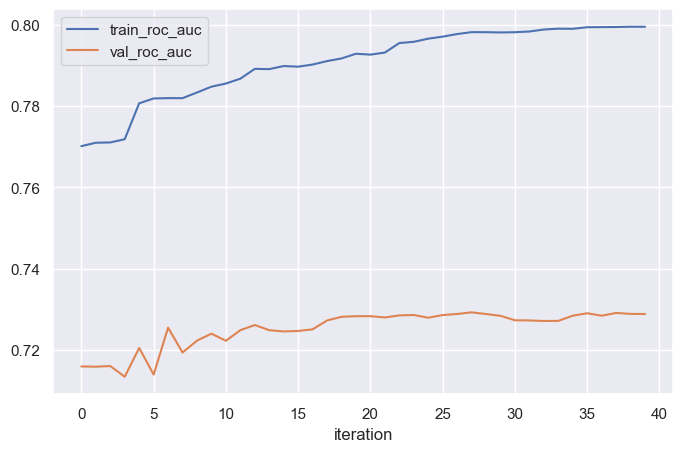

In [ ]:
model = BoostingClassifier(verbose=True,
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=42,
    early_stopping_rounds=12, 
    eval_metric="val_roc_auc")
model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
print(f"Остановились на итерации {len(model.history['val_roc_auc'])}")
print(f"Лучших деревьев в модели: {len(model.models)}")
print(f"Лучший val_roc_auc: {model.history['val_roc_auc'].max()}")

model.plot_history(["train_roc_auc", "val_roc_auc"])

## Categorical features and sampling strategies

In [ ]:
# Restore all features, including categorical variables

X_train = X[X["year"] < 2011].values
X_valid = X[X["year"] == 2011].values
X_test = X[X["year"] == 2013].values

Лучший val_roc_auc: 0.7749913326772477


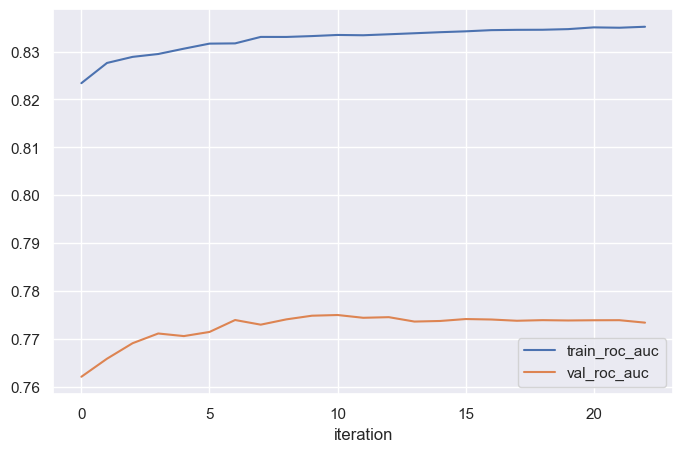

In [ ]:
model = BoostingClassifier(verbose=True,
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=42,
    early_stopping_rounds=12, 
    eval_metric="val_roc_auc",
    cat_features =[10]
    )
model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)
print(f"Лучший val_roc_auc: {model.history['val_roc_auc'].max()}")

model.plot_history(["train_roc_auc", "val_roc_auc"])

Лучший val_roc_auc: 0.7749913326772477
Лучший val_roc_auc: 0.7751357455361141


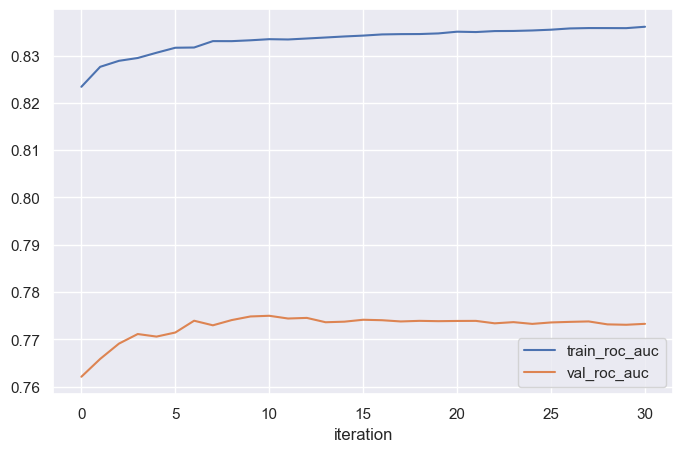

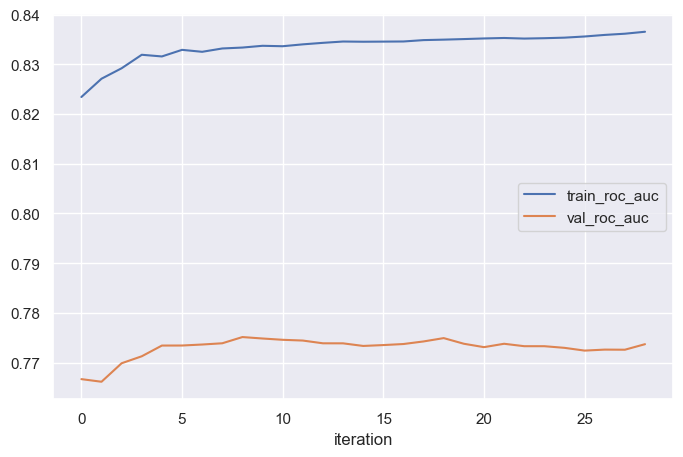

In [ ]:
m_bern = BoostingClassifier(
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=42,
    bootstrap_type="Bernoulli",
    subsample=0.7,
    verbose=True,
    early_stopping_rounds=20, 
    eval_metric="val_roc_auc",
    cat_features =[10]


)
m_bern.fit(X_train, y_train, eval_set=(X_valid, y_valid))
print(f"Лучший val_roc_auc: {m_bern.history['val_roc_auc'].max()}")

m_bern.plot_history(["train_roc_auc", "val_roc_auc"])

m_bay = BoostingClassifier(
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=42,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    verbose=True,
    early_stopping_rounds=20, 
    eval_metric="val_roc_auc",
    cat_features =[10]


)
m_bay.fit(X_train, y_train, eval_set=(X_valid, y_valid))
print(f"Лучший val_roc_auc: {m_bay.history['val_roc_auc'].max()}")

m_bay.plot_history(["train_roc_auc", "val_roc_auc"])

Лучший val_roc_auc: 0.770605620201501


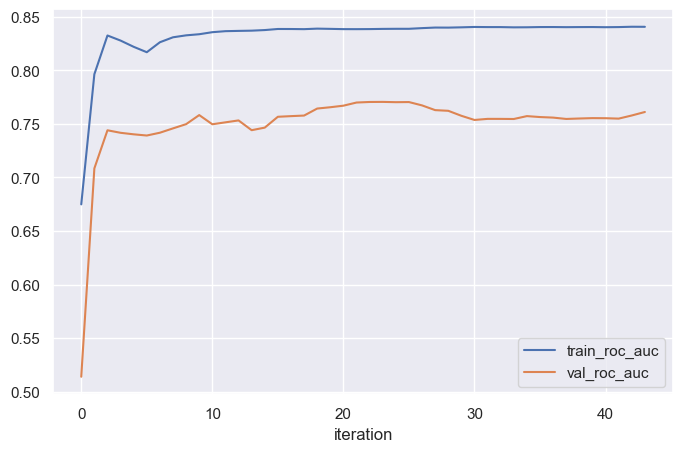

In [ ]:
model = BoostingClassifier(
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=42,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    verbose=True,
    early_stopping_rounds=20, 
    eval_metric="val_roc_auc",
    cat_features =[10],
    rsm = 0.5,

)
model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
print(f"Лучший val_roc_auc: {model.history['val_roc_auc'].max()}")

model.plot_history(["train_roc_auc", "val_roc_auc"])

Лучший val_roc_auc: 0.7756494957984725


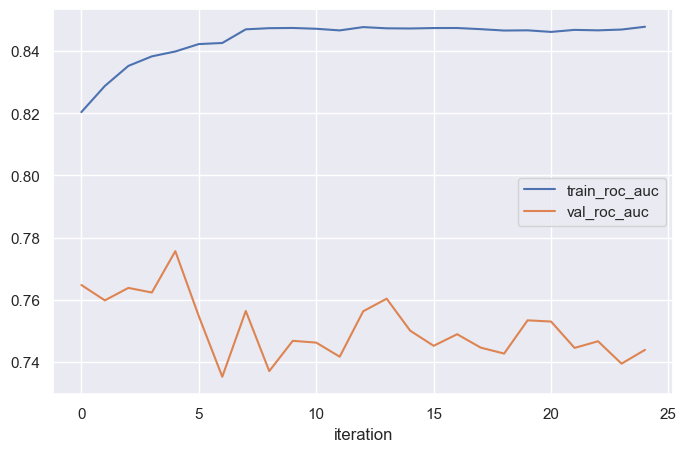

In [ ]:
model = BoostingClassifier(
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=42,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    verbose=True,
    early_stopping_rounds=20, 
    eval_metric="val_roc_auc",
    cat_features =[10],
    rsm = 0.5,
    goss = True,
    goss_k=0.5,

)
model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
print(f"Лучший val_roc_auc: {model.history['val_roc_auc'].max()}")

model.plot_history(["train_roc_auc", "val_roc_auc"])

Лучший val_roc_auc: 0.8100782667222264


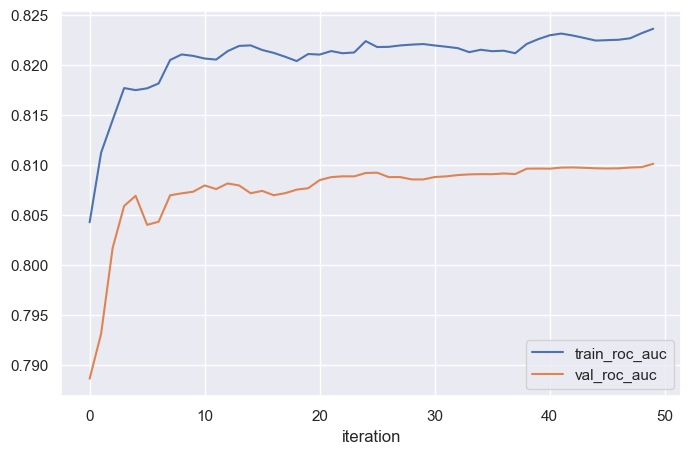

In [ ]:
model = BoostingClassifier(
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=42,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    verbose=True,
    early_stopping_rounds=20, 
    eval_metric="val_roc_auc",
    cat_features =[10],
    rsm = 0.5,
    goss = True,
    goss_k=0.5,
    quantization_type="uniform",
    
)
model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
print(f"Лучший val_roc_auc: {model.history['val_roc_auc'].max()}")

model.plot_history(["train_roc_auc", "val_roc_auc"])

## Quantization and robustness

Quantization replaces continuous values with bin identifiers. It can reduce the influence of extreme observations because values in the same bin become indistinguishable. Missing values still require an explicit policy—such as a dedicated bin—because arbitrary numerical sentinels can create artificial order and distance.

## Feature importance

Топ признаки: [('occupation', np.float64(0.3638575714425595)), ('occ', np.float64(0.3538840937375761)), ('sch', np.float64(0.08765381695258961))]


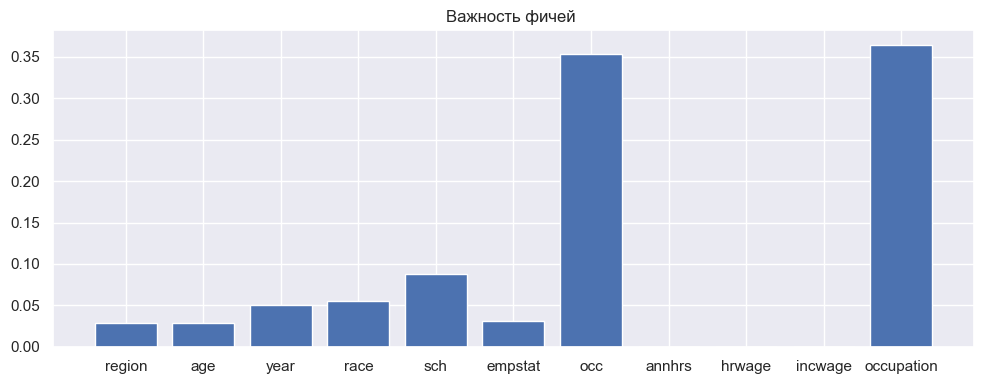

In [ ]:
import matplotlib.pyplot as plt
fi = model.get_feature_importance()
feature_names = ["region", "age", "year", "race", "sch", "empstat", "occ", "annhrs", "hrwage", "incwage", "occupation"]

plt.figure(figsize=(10, 4))
plt.bar(feature_names[:len(fi)], fi)
plt.title("Важность фичей ")
plt.tight_layout()
plt.show()

print("Топ признаки:", sorted(zip(feature_names, fi), key=lambda x: -x[1])[:3])

## Why boosting linear learners remains linear

A weighted sum of linear base learners is still a linear function. Boosting linear models can improve optimization behaviour, but it does not increase the expressive power beyond a single unconstrained linear model. Non-linearity must come from the base learner or from transformed input features.

## Linear learners

In [ ]:

import time
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import log_loss
cat_cols = [3, 5, 6, 10]
num_cols = [c for c in range(X_train.shape[1]) if c not in cat_cols]
X_tr_df = pd.DataFrame(X_train)
X_val_df = pd.DataFrame(X_valid)
for col in num_cols:
    X_tr_df[col]= pd.to_numeric(X_tr_df[col])
    X_val_df[col] = pd.to_numeric(X_val_df[col])
preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols), ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])
X_tr_sc= preprocessor.fit_transform(X_tr_df)
X_val_sc = preprocessor.transform(X_val_df)
y_tr= (y_train > 0).astype(int)
y_val = (y_valid > 0).astype(int)
dtrain = xgb.DMatrix(X_tr_sc, label=y_tr)
dval= xgb.DMatrix(X_val_sc,label=y_val)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "booster": "gblinear",
    "learning_rate": 0.5,
    "reg_lambda": 0.1,
    "updater": "shotgun",
    "verbosity": 0,
    "seed": 42,
}
evals_result = {}
t0 = time.time()
model_gblinear = xgb.train(
    params, dtrain, num_boost_round=50,
    evals=[(dtrain, "train"), (dval, "val")],
    evals_result=evals_result,
    verbose_eval=False,
)
xgb_time = time.time() - t0
xgb_train_loss = evals_result["train"]["logloss"]
xgb_val_loss= evals_result["val"]["logloss"]
print(f"XGBoost gblinear: {xgb_time}, лучшая ошибка: {min(xgb_val_loss)}")

XGBoost gblinear: 42.786771059036255, лучшая ошибка: 0.6526763875480881


In [ ]:
from sklearn.linear_model import SGDClassifier

rng = np.random.RandomState(42)
idx = rng.choice(len(X_tr_sc), 5000, replace=False)
X_tr_sub, y_tr_sub = X_tr_sc[idx], y_tr[idx]
sgd = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    alpha=0.001,
    random_state=42,
    shuffle=True,
)
sgd_train_loss = []
sgd_val_loss= []
classes = np.array([0, 1])
t0 = time.time()
for _ in range(50):
    sgd.partial_fit(X_tr_sc, y_tr, classes=classes)
    sgd_train_loss.append(log_loss(y_tr_sub, sgd.predict_proba(X_tr_sub)))
    sgd_val_loss.append(log_loss(y_val, sgd.predict_proba(X_val_sc)))
sgd_time = time.time() - t0
print(f"SGDClassifier: {sgd_time}, лучшая ошибка: {min(sgd_val_loss)}")

SGDClassifier: 43.24831795692444, лучшая ошибка: 0.8262993343424611


XGBoost gblinear: 42.786771059036255
SGDClassifier: 43.24831795692444


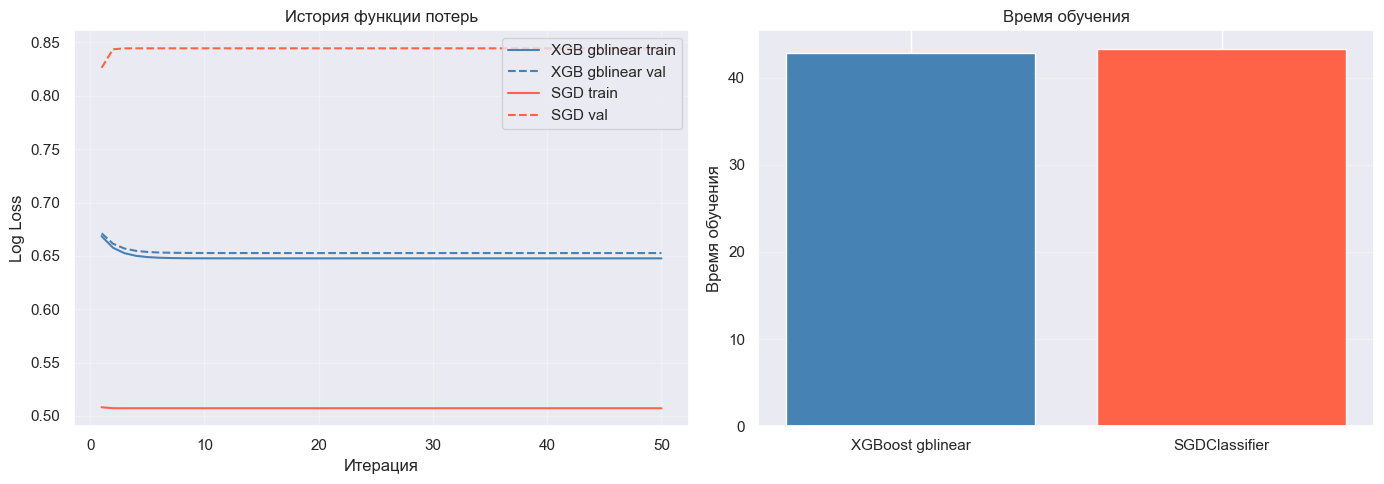

In [ ]:
import matplotlib.pyplot as plt
n = len(xgb_train_loss)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, n+1), xgb_train_loss, label="XGB gblinear train", color="steelblue")
axes[0].plot(range(1, n+1), xgb_val_loss,label="XGB gblinear val",color="steelblue", linestyle="--")
axes[0].plot(range(1, len(sgd_train_loss)+1), sgd_train_loss, label="SGD train", color="tomato")
axes[0].plot(range(1, len(sgd_val_loss)+1),sgd_val_loss,label="SGD val",color="tomato", linestyle="--")
axes[0].set_xlabel("Итерация")
axes[0].set_ylabel("Log Loss")
axes[0].set_title("История функции потерь")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(["XGBoost gblinear", "SGDClassifier"], [xgb_time, sgd_time], color=["steelblue", "tomato"])
axes[1].set_ylabel("Время обучения")
axes[1].set_title("Время обучения")
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"XGBoost gblinear: {xgb_time}")
print(f"SGDClassifier: {sgd_time}")

## Linear boosting versus stochastic gradient descent

In this experiment, XGBoost with the `gblinear` booster reached a lower validation loss than the configured `SGDClassifier`, while training times were similar. This comparison is configuration-dependent: both methods optimize linear decision functions, but their update rules, regularization, and stopping behaviour differ.

## Hyperparameter optimization

In [ ]:
import optuna

In [ ]:
def objective(study, model="custom_boosting"):
    # Boosting hyperparameters
    boosting_params = {
    "n_estimators":  study.suggest_int("n_estimators", 30, 500),
    "learning_rate": study.suggest_float("learning_rate", 0.001, 0.3, log=True),
    "rsm": study.suggest_float("rsm", 0.2, 1.0),    
}

    # параметры дерева
    tree_params = {"max_depth": study.suggest_int("max_depth", 2, 9)}

    # параметры, зависящие от некоторого условия (e.g. subsample только для Bernoulli)
    # если не делать их условными, можно испортить процесс оптимизации
    sampling = study.suggest_categorical("sampling", ["Bernoulli", "Bayesian", "GOSS", None])
    conditional_params = {}
    if sampling == "Bernoulli":
        conditional_params["bootstrap_type"] = "Bernoulli"
        conditional_params["subsample"] = study.suggest_float("subsample", 0.5, 1.0)
    elif sampling == "Bayesian":
        conditional_params["bootstrap_type"] = "Bayesian"
        conditional_params["bagging_temperature"] = study.suggest_float("bagging_temperature", 0.0, 2.0)
    elif sampling == "GOSS":
        conditional_params["bootstrap_type"] = None
        conditional_params["goss"] = True
        conditional_params["goss_k"] = study.suggest_float("goss_k", 0.1, 0.5)
        conditional_params["subsample"] = study.suggest_float("goss_subsample", 0.1, 0.5)
    else:
        conditional_params["bootstrap_type"] = None

    quantization_type = study.suggest_categorical("quantization_type", ["uniform", "quantile", None])
    conditional_params["quantization_type"] = quantization_type
    if quantization_type is not None:
        conditional_params["nbins"] = study.suggest_int("nbins", 64, 255)

    model = BoostingClassifier(
        base_model_params=tree_params,
        random_state=42,
        verbose=False,
        early_stopping_rounds=10,
        eval_metric="val_roc_auc",
        cat_features=[3,5,6,10],
        **boosting_params,
        **conditional_params,
    )
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
    return model.history["val_roc_auc"].max()


In [ ]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=25, show_progress_bar=True)

print("Лучшие параметры:", study.best_params)
print(f"Лучший val roc-auc: {study.best_value}")

[I 2026-05-25 23:13:49,815] Trial 11 finished with value: 0.8323000994581509 and parameters: {'n_estimators': 32, 'learning_rate': 0.04293522495483973, 'rsm': 0.48487297866799506, 'max_depth': 5, 'sampling': 'GOSS', 'goss_k': 0.4831282850312477, 'goss_subsample': 0.4872532545098501, 'quantization_type': 'uniform', 'nbins': 64}. Best is trial 10 with value: 0.8336053534045363.
[I 2026-05-25 23:14:01,223] Trial 12 finished with value: 0.8335266785973863 and parameters: {'n_estimators': 33, 'learning_rate': 0.030400633843317194, 'rsm': 0.5009052926981201, 'max_depth': 5, 'sampling': 'GOSS', 'goss_k': 0.48106166739752426, 'goss_subsample': 0.49574921517081066, 'quantization_type': 'uniform', 'nbins': 64}. Best is trial 10 with value: 0.8336053534045363.
[I 2026-05-25 23:14:08,418] Trial 13 finished with value: 0.8331641646738948 and parameters: {'n_estimators': 99, 'learning_rate': 0.028831067359745163, 'rsm': 0.514491797842572, 'max_depth': 4, 'sampling': 'GOSS', 'goss_k': 0.4801109869797

In [ ]:
study.best_params

{'n_estimators': 142,
 'learning_rate': 0.29806507238549373,
 'rsm': 0.8028457181790817,
 'max_depth': 8,
 'sampling': 'GOSS',
 'goss_k': 0.2527998447162595,
 'goss_subsample': 0.4140593735909641,
 'quantization_type': 'uniform',
 'nbins': 171}

In [ ]:
best_params = study.best_params
print(best_params)

trained_model_31 = BoostingClassifier(
    base_model_params={"max_depth": best_params["max_depth"]},
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    rsm=best_params["rsm"],
    cat_features=[3, 5, 6, 10],
    random_state=42,
    early_stopping_rounds=10,
    eval_metric="val_roc_auc",
    bootstrap_type=None,
    goss=True,
    goss_k=best_params["goss_k"],
    subsample=best_params["goss_subsample"],
    quantization_type=best_params["quantization_type"],
    nbins=best_params["nbins"],
    verbose=True,
)

trained_model_31.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(f"Лучший roc-auc: {trained_model_31.history['val_roc_auc'].max()}")

{'n_estimators': 142, 'learning_rate': 0.29806507238549373, 'rsm': 0.8028457181790817, 'max_depth': 8, 'sampling': 'GOSS', 'goss_k': 0.2527998447162595, 'goss_subsample': 0.4140593735909641, 'quantization_type': 'uniform', 'nbins': 171}
Лучший roc-auc: 0.8385603320752176


In [ ]:
from optuna.integration import LightGBMPruningCallback
import lightgbm as lgb

X_tr = trained_model_31.transform(X_train)
X_val_lgb = trained_model_31.transform(X_valid)

def objective_lgbm(study):
    boosting_params = {
        "num_boost_round": study.suggest_int("n_estimators", 30, 500),
        "learning_rate": study.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "colsample_bytree":study.suggest_float("rsm", 0.2, 1.0),
    }
    tree_params = {"max_depth": study.suggest_int("max_depth", 2, 9)}
    sampling = study.suggest_categorical("sampling", ["Bernoulli", "Bayesian", "GOSS", None])
    conditional_params = {}
    if sampling == "Bernoulli":
        conditional_params["bagging_fraction"] = study.suggest_float("subsample", 0.5, 1.0)
        conditional_params["bagging_freq"] = 1
    elif sampling == "Bayesian":
        conditional_params["bagging_fraction"] = study.suggest_float("bagging_temperature", 0.5, 1.0)
        conditional_params["bagging_freq"] = 1
    elif sampling == "GOSS":
        conditional_params["boosting_type"] = "goss"
        conditional_params["top_rate"] = study.suggest_float("goss_k", 0.1, 0.5)
        conditional_params["other_rate"] = study.suggest_float("goss_subsample", 0.1, 0.5)
    quantization_type = study.suggest_categorical("quantization_type", ["uniform", "quantile", None])
    if quantization_type is not None:
        conditional_params["max_bin"] = study.suggest_int("nbins", 64, 255)
    params = {
        "objective": "binary", "metric": "auc", "verbosity": -1,
        **tree_params, **conditional_params,
        "learning_rate": boosting_params["learning_rate"],
        "colsample_bytree": boosting_params["colsample_bytree"],
    }
    model = lgb.train(
        params,
        lgb.Dataset(X_tr, label=y_train),
        num_boost_round=boosting_params["num_boost_round"],
        valid_sets=[lgb.Dataset(X_val_lgb, label=y_valid)],
        callbacks=[
            LightGBMPruningCallback(study, "auc"),
            lgb.early_stopping(10, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    return model.best_score["valid_0"]["auc"]

study_lgbm = optuna.create_study(direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=20),
)
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)
print(f"Прунировано: {sum(t.state == optuna.trial.TrialState.PRUNED for t in study_lgbm.trials)}")
print("Лучшие параметры:", study_lgbm.best_params)
print(f"Лучший val roc-auc: {study_lgbm.best_value}")

[I 2026-05-25 23:16:13,212] Trial 37 finished with value: 0.8309839021557538 and parameters: {'n_estimators': 373, 'learning_rate': 0.041945256691411026, 'rsm': 0.367735830231339, 'max_depth': 8, 'sampling': 'GOSS', 'goss_k': 0.3710260129597129, 'goss_subsample': 0.10617883420374141, 'quantization_type': 'uniform', 'nbins': 233}. Best is trial 9 with value: 0.8365937115023444.
[I 2026-05-25 23:16:13,402] Trial 38 finished with value: 0.8283348246388118 and parameters: {'n_estimators': 187, 'learning_rate': 0.07032598596427984, 'rsm': 0.2493637217685068, 'max_depth': 9, 'sampling': 'Bernoulli', 'subsample': 0.5284943071103252, 'quantization_type': 'quantile', 'nbins': 138}. Best is trial 9 with value: 0.8365937115023444.
[I 2026-05-25 23:16:13,636] Trial 39 pruned. Trial was pruned at iteration 20.
[I 2026-05-25 23:16:13,791] Trial 40 finished with value: 0.8312794989500433 and parameters: {'n_estimators': 316, 'learning_rate': 0.08096842917471242, 'rsm': 0.8304200967281394, 'max_depth'

## Model-family comparison

LightGBM provides a strong speed–quality trade-off for this tabular dataset and supports categorical features efficiently. CatBoost is a natural alternative when categorical variables are central and careful target-statistic handling is desirable. The preferred model should ultimately be selected using the same validation protocol rather than library defaults.

In [ ]:
import xgboost as xgb
from optuna.integration import XGBoostPruningCallback

X_tr_xgb= trained_model_31.transform(X_train)
X_val_xgb = trained_model_31.transform(X_valid)
dtrain = xgb.DMatrix(X_tr_xgb,  label=(y_train > 0).astype(int))
dval = xgb.DMatrix(X_val_xgb, label=(y_valid > 0).astype(int))
BASE_PARAMS = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "learning_rate": 0.05,
    "max_depth": 6,
    "colsample_bytree": 0.7,
    "subsample": 0.8,
    "verbosity": 0,
    "seed": 42,
}

def objective_xgb(trial):
    params = {
        **BASE_PARAMS,
        "alpha": trial.suggest_float("alpha",  1e-8, 10.0, log=True),
        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),
    }
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=200,
        evals=[(dval, "validation")],
        early_stopping_rounds=10,
        callbacks=[XGBoostPruningCallback(trial, "validation-auc")],
    )
    return model.best_score

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=20),
)
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)
print(f"Прунировано: {sum(t.state == optuna.trial.TrialState.PRUNED for t in study_xgb.trials)}")
print("Лучшие параметры:", study_xgb.best_params)
print(f"Лучший val roc-auc: {study_xgb.best_value}")

base_model_no_reg = xgb.train(
    BASE_PARAMS,
    dtrain,
    num_boost_round=200,
    evals=[(dval, "validation")],
    early_stopping_rounds=10,
    verbose_eval=False,
)

print(f"Без alpha/lambda val roc-auc: {base_model_no_reg.best_score}")
print(f"С подобранными alpha/lambda val roc-auc: {study_xgb.best_value}")
print(f"Разница: {study_xgb.best_value - base_model_no_reg.best_score}")

[11]	validation-auc:0.82504
[12]	validation-auc:0.82490
[13]	validation-auc:0.82543
[14]	validation-auc:0.82538
[15]	validation-auc:0.82528
[16]	validation-auc:0.82503
[17]	validation-auc:0.82521
[18]	validation-auc:0.82745
[19]	validation-auc:0.82942
[I 2026-05-25 23:16:21,667] Trial 29 pruned. Trial was pruned at iteration 20.
Прунировано: 17
Лучшие параметры: {'alpha': 0.0003084065881779716, 'lambda': 0.11716648885619209}
Лучший val roc-auc: 0.8325655601351293
Без alpha/lambda val roc-auc: 0.8323022528259805
С подобранными alpha/lambda val roc-auc: 0.8325655601351293
Разница: 0.00026330730914880807


## Effect of regularization

Regularization reduced the gap between training and validation performance and made the fitted model less sensitive to individual observations. Excessively strong regularization caused underfitting, so its value was selected jointly with tree complexity and learning rate.

## Boosting and random-forest comparison

In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
y_tr = (y_train > 0).astype(int)
y_val = (y_valid > 0).astype(int)

lgb_rf = lgb.LGBMClassifier(
    boosting_type="rf",
    n_estimators=1000,
    num_leaves=255,
    feature_fraction=0.3,
    bagging_fraction=0.8,
    bagging_freq=1,
    min_child_samples=5,
    n_jobs=-1,
    random_state=42,
)
X_tr  = pd.DataFrame(X_train)
X_val = pd.DataFrame(X_valid)
for col in [3, 5, 6, 10]:
    cats = pd.Categorical(X_tr[col])
    X_tr[col] = cats.codes
    X_val[col] = pd.Categorical(X_val[col], categories=cats.categories).codes

for col in X_tr.columns:
    if col not in [3, 5, 6, 10]:
        X_tr[col] = pd.to_numeric(X_tr[col])
        X_val[col] = pd.to_numeric(X_val[col])
lgb_rf.fit(X_tr, y_tr, categorical_feature=[3, 5, 6, 10])
pred = lgb_rf.predict_proba(X_val)[:, 1]
print(f"Val roc-auc: {roc_auc_score(y_val, pred)}")

Val roc-auc: 0.7860891209482543


## Boosting versus random forests

Boosting performed better in this experiment because each successive learner focused on errors left by the current ensemble. Random forests train trees independently and mainly reduce variance through averaging. The result is dataset-dependent and should not be treated as a universal ranking.

## Ensembling and calibration

In [ ]:
from catboost import CatBoostClassifier, sum_models
from sklearn.model_selection import StratifiedKFold

y_tr= (y_train > 0).astype(int)
y_val_bin = (y_valid > 0).astype(int)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = []
for fold, (train_idx, _) in enumerate(kf.split(X_train, y_tr)):
    model = CatBoostClassifier(
        iterations=300,
        cat_features=[3, 5, 6, 10],
        random_seed=fold,
        verbose=False,
    )
    model.fit(X_train[train_idx], y_tr[train_idx])
    models.append(model)

n = len(models)
combined = sum_models(models, weights=[1/n] * n)
pred = combined.predict(X_valid, prediction_type='Probability')[:, 1]
print(f"Val roc-auc: {roc_auc_score(y_val_bin, pred):.4f}")

Val roc-auc: 0.8154


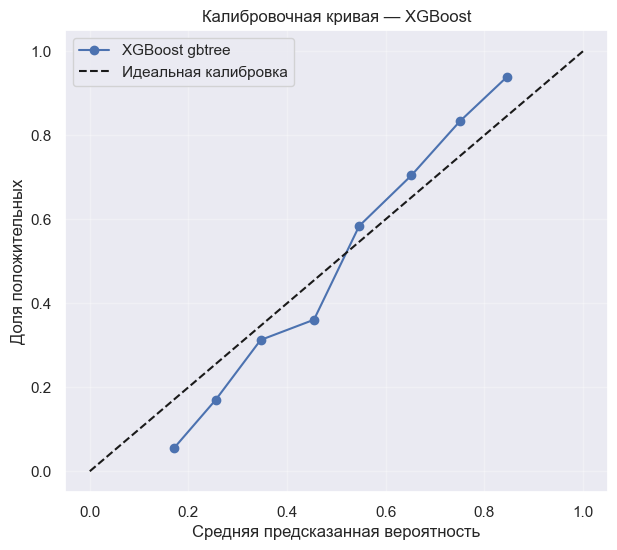

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import xgboost as xgb
y_val_bin = (y_valid > 0).astype(int)
y_tr_bin = (y_train > 0).astype(int)
best_params_xgb = {**BASE_PARAMS, **study_xgb.best_params}
dtrain_36 = xgb.DMatrix(X_tr_xgb, label=y_tr_bin)
dval_36= xgb.DMatrix(X_val_xgb, label=y_val_bin)
best_xgb = xgb.train(
    best_params_xgb, dtrain_36, num_boost_round=200,
    evals=[(dval_36, "val")], early_stopping_rounds=10,
    verbose_eval=False,
)
y_prob_xgb = best_xgb.predict(dval_36)
prob_true_xgb, prob_pred_xgb = calibration_curve(y_val_bin, y_prob_xgb, n_bins=10)
plt.figure(figsize=(7, 6))
plt.plot(prob_pred_xgb, prob_true_xgb, marker='o', label='XGBoost gbtree')
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных')
plt.title('Калибровочная кривая — XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Probability calibration

The final section compares the calibration curves of gradient boosting and logistic regression, then evaluates post-hoc isotonic calibration. Ranking metrics and calibration metrics are reported separately because a model may order observations correctly while producing unreliable probability estimates.

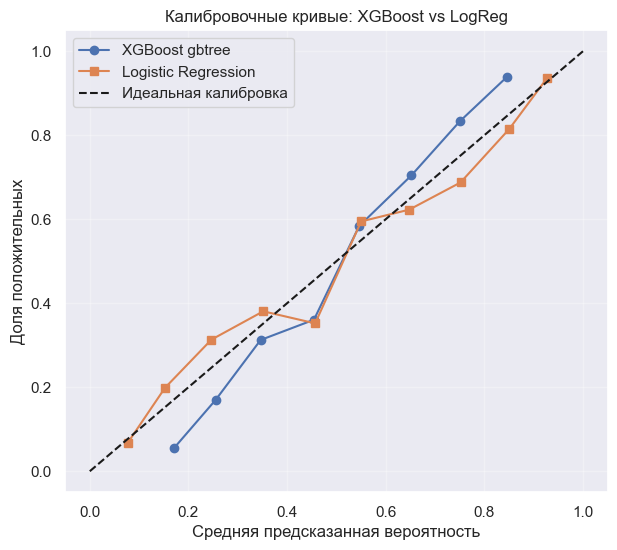

In [ ]:

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_tr_xgb, y_tr_bin)
y_prob_lr = lr.predict_proba(X_val_xgb)[:, 1]
prob_true_lr, prob_pred_lr = calibration_curve(y_val_bin, y_prob_lr, n_bins=10)
plt.figure(figsize=(7, 6))
plt.plot(prob_pred_xgb, prob_true_xgb, marker='o', label='XGBoost gbtree')
plt.plot(prob_pred_lr, prob_true_lr, marker='s', label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных')
plt.title('Калибровочные кривые: XGBoost vs LogReg')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

До калибровки:
ROC-AUC: 0.83286
LogLoss: 0.53403
BrierScore: 0.17753
После калибровки:
ROC-AUC: 0.83277
LogLoss: 0.49982
BrierScore: 0.16656


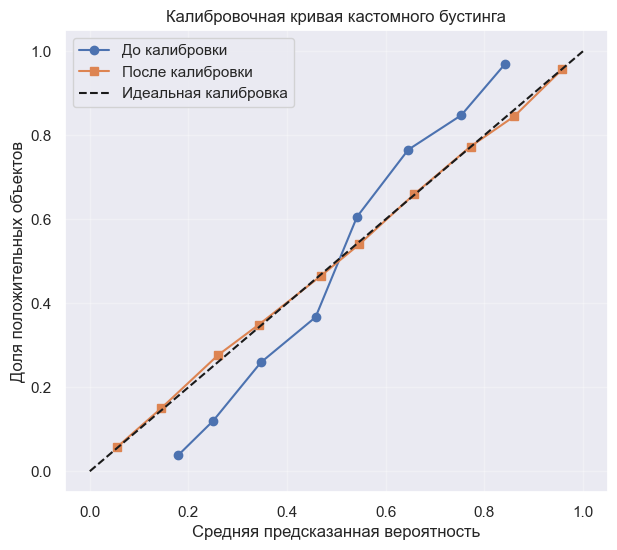

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

y_valid_bin = (y_valid > 0).astype(int)
y_test_bin = (y_test > 0).astype(int)

best_custom = trained_model_31

p_valid_before = best_custom.predict_proba(X_valid)[:, 1]
p_test_before = best_custom.predict_proba(X_test)[:, 1]

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_valid_before, y_valid_bin)

p_test_after = iso.predict(p_test_before)
p_test_after = np.clip(p_test_after, 1e-15, 1 - 1e-15)

print("До калибровки:")
print(f"ROC-AUC: {roc_auc_score(y_test_bin, p_test_before):.5f}")
print(f"LogLoss: {log_loss(y_test_bin, p_test_before):.5f}")
print(f"BrierScore: {brier_score_loss(y_test_bin, p_test_before):.5f}")

print("\nПосле калибровки:")
print(f"ROC-AUC: {roc_auc_score(y_test_bin, p_test_after):.5f}")
print(f"LogLoss: {log_loss(y_test_bin, p_test_after):.5f}")
print(f"BrierScore: {brier_score_loss(y_test_bin, p_test_after):.5f}")

prob_true_before, prob_pred_before = calibration_curve(
    y_test_bin, p_test_before, n_bins=10
)
prob_true_after, prob_pred_after = calibration_curve(
    y_test_bin, p_test_after, n_bins=10
)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred_before, prob_true_before, marker="o", label="До калибровки")
plt.plot(prob_pred_after, prob_true_after, marker="s", label="После калибровки")
plt.plot([0, 1], [0, 1], "k--", label="Идеальная калибровка")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Доля положительных объектов")
plt.title("Калибровочная кривая кастомного бустинга")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Calibration results

Isotonic calibration leaves ROC AUC almost unchanged because it applies a monotonic transformation and therefore largely preserves ranking. Log loss and Brier score improve because the predicted probabilities better match observed frequencies. This distinction matters whenever probabilities are used for decisions rather than ranking alone.

## Conclusion

The experiments show that predictive ranking, probability quality, and computational efficiency are distinct objectives. Gradient boosting provides strong tabular performance, while post-hoc calibration improves the reliability of predicted probabilities without materially changing ranking. A production or scientific application should also report uncertainty across repeated temporal splits and document how missing and categorical values are handled.